In [1]:
import pandas as pd
import matplotlib.pyplot  as plt
import os

### Подготовка данных для использования нейросетью

In [2]:
dirname = os.path.join(os.path.abspath(os.curdir), 'data', 'underwork')

raw_data = {"3":(), "5":(), "8":(), "10":(), "14":(), "15":()}
for v in raw_data:
    tsdf_c = pd.read_csv(os.path.join(os.sep, dirname, v, 'calm_p.csv'))
    tsdf_w = pd.read_csv(os.path.join(os.sep, dirname, v,  'work_p.csv'))
    tsdf_m = pd.read_csv(os.path.join(os.sep, dirname, v, 'meta_p.csv'))
    raw_data[v] = (tsdf_c, tsdf_w, tsdf_m)

In [3]:
data = {"3":(), "5":(), "8":(), "10":(), "14":(), "15":()}

for v in raw_data:
    calm = raw_data[v][0]
    work = raw_data[v][1]
    sex = raw_data[v][2].iloc[0]["values"]
    weight = raw_data[v][2].iloc[1]["values"]
    height = raw_data[v][2].iloc[2]["values"]
    calm["sex"] = sex
    calm["weight"] = weight
    calm["height"] = height
    calm["state"] = 0
    work["sex"] = sex
    work["weight"] = weight
    work["height"] = height
    work["state"] = 1
    data[v] = (calm, work)

In [4]:
validation = {"25":(), "27":()}
for v in validation:
    calm = pd.read_csv(os.path.join(os.sep, dirname, v, 'calm_p.csv'))
    work = pd.read_csv(os.path.join(os.sep, dirname, v,  'work_p.csv'))
    tsdf_m = pd.read_csv(os.path.join(os.sep, dirname, v, 'meta_p.csv'))
    sex = tsdf_m.iloc[0]["values"]
    weight = tsdf_m.iloc[1]["values"]
    height = tsdf_m.iloc[2]["values"]
    calm["sex"] = sex
    calm["weight"] = weight
    calm["height"] = height
    calm["state"] = 0
    work["sex"] = sex
    work["weight"] = weight
    work["height"] = height
    work["state"] = 1
    validation[v] = (calm, work)

# LSTM

#### Нейронные сети

Искусственная нейронная сеть представляет собой слоистую структуру из связанных
нейронов, вдохновленную биологическими нейронными сетями. Это не один алгоритм,
а комбинация различных алгоритмов, которая позволяет нам выполнять сложные
операции с данными.

#### Рекуррентные нейронные сети
Рекуррентные нейронные сети (RNN) — это класс нейронных сетей, которые хороши
для моделирования последовательных данных, таких как временные ряды или
естественный язык, значения сенсоров в течении некоторого временного промежутка.
В общем смысле, RNN применяются в моделировании языка (англ. Language Modelling)
и генерация текста, распознавании речи, генерации описания к изображениям (не
только текстового, но и по возможным другим параметрам) или маркировке видео
(англ. Video Tagging)

Подобно нейронным сетям с прямой связью (англ. Feedforward Neural Network, FNN)
и CNN, рекуррентные нейронные сети используют обучающие данные для изменения
своих весов. Основным отличием от других видов сетей является ''память'', суть
которой в том, что в процессе обработки входной информации текущим слоем в RNN,
используются входные параметры к некоторым предыдущим слоям сети (таким образом
влияя на результат работы текущего слоя сети). В то время как традиционные
глубокие нейронные сети предполагают, что входные и выходные данные слоев
независимы друг от друга, выходы рекуррентных нейронных сетей зависят от
предшествующих элементов внутри последовательности этих слоев. Хотя будущие
преобразования также могут быть полезны для определения результата данной
последовательности, однонаправленные рекуррентные нейронные сети не могут
учитывать эти преобразования в своих прогнозах.

Однако при использовании первых архитектур RNN возникала проблема потери
способности связывать информацию из-за уменьшения аргументов слоев сети на
текущий обрабатываемый слой при увеличении ''расстояния'' между слоем (то есть
чем дальше слой $B$ от слоя $A$, тем меньше слой $A$ влияет на слой $B$). Время
от времени значение градиента может становиться бесконечно малым, что
препятствует обновлению значения веса. На практике была представлена реализация
модификации рекуррентной нейросети, которая способна к обучению долговременным
зависимостям. Название такого подкласса RNN "--- сеть с долгой краткосрочной
памятью (англ. Long Short-Term Memory, LSTM).

![Виды ячеек разных сетей](pics/rnn-lstm.png "Title")

![Легенда](pics/legend.png "Title")

#### LSTM

Это особый вид рекуррентной нейронной сети, способной изучать долгосрочные
зависимости в данных. Это достигается за счет того, что повторяющийся модуль
модели имеет комбинацию четырех слоев, взаимодействующих друг с другом.

На рисунке посередине изображены четыре слоя нейронной сети LSTM в желтых
прямоугольниках ($\sigma$, $\tanh$), ввод через $x_t$ и состояние ячейки через
$h_t$. Модуль LSTM имеет состояние ячейки и три шлюза, что дает им возможность
выборочно изучать, отключать или сохранять информацию от каждого из модулей.
Состояние ячейки в LSTM помогает информации проходить через единицы без
изменения, позволяя только несколько линейных взаимодействий.

Таким образом, для каждого элемента входной последовательности каждый $t$-ый слой
LSTM модели осуществляет следующие вычисления:

$$i_t = \sigma(W_{ii} x_t + b_{ii} + W_{hi} h_{t - 1} + b_{hi}) ;$$
$$f_t = \sigma(W_{if} x_t + b_{if} + W_{hf} h_{t - 1} + b_{hf}) ;$$
$$g_t = \tanh(W_{ig} x_t + b_{ig} + W_{hg} h_{t - 1} + b_{hg}) ;$$
$$o_t = \sigma(W_{io} x_t + b_{io} + W_{ho} h_{t - 1} + b_{ho}) ;$$
$$c_t = f_t \odot c_{t - 1} + i_t \odot g_t ;$$
$$h_t = o_t \odot \tanh(c_t) ,$$

где $h_t, c_t, x_t$ - скрытое состояние слоя модели, состояние клетки и
входной параметр в момент времени $t$ соответственно; $h_{t - 1}$ определяет
скрытое состояние слоя в момент времени $t - 1$ или начальное скрытое состояние
в момент времени $o$. Элементы $i_t, f_t, g_t, o_t$ являются входными,
забывающими, клеточными и выходными воротами соответственно. Символ $\sigma$
определяет функцию сигмоиды, $\odot$ - поэлементное произведение, также
называемое произведением Адамара.

#### Функция по разделению набора данных на обучающую и тестовую выборки

In [5]:
def data_split(ts, param="1", train_percentage=0.67):
    timeseries = ts[["1"]].values.astype('float32')
    train_size = int(len(timeseries) * train_percentage)
    train, test = timeseries[:train_size], timeseries[train_size:]
    return train, test, timeseries

#### Подготовка последовательностей через Lazy Loading   Задание 1

Вместо предварительного создания всех окон временного ряда используется пользовательский класс `TimeSeriesDataset`. Он формирует одно окно только в момент обращения к нему из `DataLoader`, поэтому не требуется хранить в памяти огромные тензоры `X_train` и `X_test`.

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    """
    Ленивый датасет для прогнозирования временного ряда.
    Окна формируются на лету, а не создаются заранее для всей выборки.
    """

    def __init__(self, data, lookback):
        self.data = torch.as_tensor(data, dtype=torch.float32)
        self.lookback = lookback

    def __len__(self):
        return len(self.data) - self.lookback

    def __getitem__(self, idx):
        # Последовательность входных значений
        X = self.data[idx:idx + self.lookback]

        # Целевая последовательность, сдвинутая на один шаг вперёд
        y = self.data[idx + 1:idx + self.lookback + 1]

        return X, y

#### С помощью класса описывается базовая нейросеть LSTM
(возможно усложнение архиктуры в целях повышения качества)

In [7]:
import torch.nn as nn
 
class AirModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=50, num_layers=1, batch_first=True)
        self.linear = nn.Linear(50, 1)
    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.linear(x)
        return x

#### Формирование исходного ряда, разделение на train/test и создание ленивых загрузчиков

In [8]:
ts = pd.DataFrame()

for v in data:
    calm = data[v][0]
    work = data[v][1]
    ts = pd.concat([ts, calm, work], sort=False, axis=0)

print("Количество наблюдений:", ts.shape[0])
train, test, total = data_split(ts)

lookback = 1

print("Размер train:", train.shape)
print("Размер test:", test.shape)
train_dataset = TimeSeriesDataset(train, lookback=lookback)
test_dataset = TimeSeriesDataset(test, lookback=lookback)

train_loader = DataLoader(train_dataset,batch_size=2048,shuffle=True,num_workers=0)

test_loader = DataLoader(test_dataset,batch_size=4096,shuffle=False,num_workers=0)

print("Количество train-окон:", len(train_dataset))
print("Количество test-окон:", len(test_dataset))
print("Количество train-батчей:", len(train_loader))
print("Количество test-батчей:", len(test_loader))


X_batch, y_batch = next(iter(train_loader))
print("Форма X_batch:", X_batch.shape)
print("Форма y_batch:", y_batch.shape)

Количество наблюдений: 670000
Размер train: (448900, 1)
Размер test: (221100, 1)
Количество train-окон: 448899
Количество test-окон: 221099
Количество train-батчей: 220
Количество test-батчей: 54
Форма X_batch: torch.Size([2048, 1, 1])
Форма y_batch: torch.Size([2048, 1, 1])


#### Создание LSTM-модели, оптимизатора и функции потерь

In [9]:
import numpy as np
import torch.optim as optim

torch.manual_seed(42)

model = AirModel()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

loss_fn = nn.MSELoss()

EPOCHS = 5

print(model)
print("Количество эпох:", EPOCHS)

AirModel(
  (lstm): LSTM(1, 50, batch_first=True)
  (linear): Linear(in_features=50, out_features=1, bias=True)
)
Количество эпох: 5


#### Обучение модели с механизмом Early Stopping
#### Задание 2 ####

После каждой эпохи оценивается ошибка на тестовой выборке. Если значение `test RMSE` не улучшается в течение заданного числа эпох, обучение прекращается, а модели возвращаются лучшие найденные веса.

In [10]:
from tqdm.auto import tqdm
import numpy as np

def evaluate_model(model, loader):
    model.eval()

    squared_error_sum = 0.0
    number_of_values = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            y_pred = model(X_batch)
            squared_error_sum += torch.sum((y_pred - y_batch) ** 2).item()
            number_of_values += y_batch.numel()

    return np.sqrt(squared_error_sum / number_of_values)


def train_model(model,train_loader,test_loader,loss_fn,optimizer,n_epochs,patience=3):
    best_test_rmse = float("inf")
    epochs_without_improvement = 0
    best_model_state = None

    train_rmse_history = []
    test_rmse_history = []

    for epoch in range(n_epochs):
        model.train()

        train_squared_error_sum = 0.0
        train_number_of_values = 0

        for X_batch, y_batch in tqdm(train_loader,desc=f"Эпоха {epoch + 1}/{n_epochs}",leave=False):
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_squared_error_sum += torch.sum((y_pred.detach() - y_batch) ** 2).item()
            train_number_of_values += y_batch.numel()

        train_rmse = np.sqrt(train_squared_error_sum / train_number_of_values)
        test_rmse = evaluate_model(model, test_loader)

        train_rmse_history.append(train_rmse)
        test_rmse_history.append(test_rmse)

        print(
            f"Epoch {epoch + 1}: "
            f"train RMSE = {train_rmse:.6f}, "
            f"test RMSE = {test_rmse:.6f}"
        )

        if test_rmse < best_test_rmse:
            best_test_rmse = test_rmse
            epochs_without_improvement = 0

            best_model_state = {key: value.detach().clone()for key, value in model.state_dict().items()}
        else:
            epochs_without_improvement += 1
            print(f"Нет улучшения: "f"{epochs_without_improvement}/{patience}")

            if epochs_without_improvement >= patience:
                print("Ранняя остановка обучения.")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, train_rmse_history, test_rmse_history

#### Запуск обучения нейросети

In [11]:
model, train_rmse_history, test_rmse_history = train_model(model=model,train_loader=train_loader,test_loader=test_loader,loss_fn=loss_fn,optimizer=optimizer,n_epochs=EPOCHS,patience=3)

print("\nЛучший итоговый test RMSE:", min(test_rmse_history))

Эпоха 1/5:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 1: train RMSE = 0.772336, test RMSE = 0.082532


Эпоха 2/5:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 2: train RMSE = 0.073465, test RMSE = 0.079186


Эпоха 3/5:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 3: train RMSE = 0.069944, test RMSE = 0.074644


Эпоха 4/5:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 4: train RMSE = 0.065382, test RMSE = 0.068926


Эпоха 5/5:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 5: train RMSE = 0.059730, test RMSE = 0.061904

Лучший итоговый test RMSE: 0.06190367888419128


#### Сохранение обученной сети

In [12]:
torch.save(model.state_dict(), f"./lstm_forecast_{EPOCHS}_epochs_state_dict.pth")
print("Веса модели сохранены.")

Веса модели сохранены.


### Пример подсчета метрик и построения графика 

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from math import sqrt

def mean_absolute_percentage_error(y_true, y_pred):
    nonzero = np.abs(y_true) > 1e-8
    if not np.any(nonzero):
        return np.nan
    return np.mean(
        np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])
    ) * 100


def predictions_from_loader(model, loader):
    """Получает реальные значения и прогнозы батчами."""
    model.eval()
    true_parts = []
    pred_parts = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            y_pred = model(X_batch)
            true_parts.append(y_batch[:, -1, :].cpu().numpy())
            pred_parts.append(y_pred[:, -1, :].cpu().numpy())

    return (
        np.concatenate(true_parts).ravel(),
        np.concatenate(pred_parts).ravel()
    )


def validate(true, pred):
    print("MSE:", mean_squared_error(true, pred))
    print("RMSE:", sqrt(mean_squared_error(true, pred)))
    print("MAE:", mean_absolute_error(true, pred))
    print("MAPE:", mean_absolute_percentage_error(true, pred))
    print("R2:", r2_score(true, pred))


# Метрики на тестовой части обучающих пользователей
test_true, test_pred = predictions_from_loader(model, test_loader)
print("Метрики на тестовой выборке:")
validate(test_true, test_pred)

Метрики на тестовой выборке:
MSE: 0.003832065500319004
RMSE: 0.061903679214720383
MAE: 0.041769299656152725
MAPE: 3.1802003
R2: 0.840794026851654


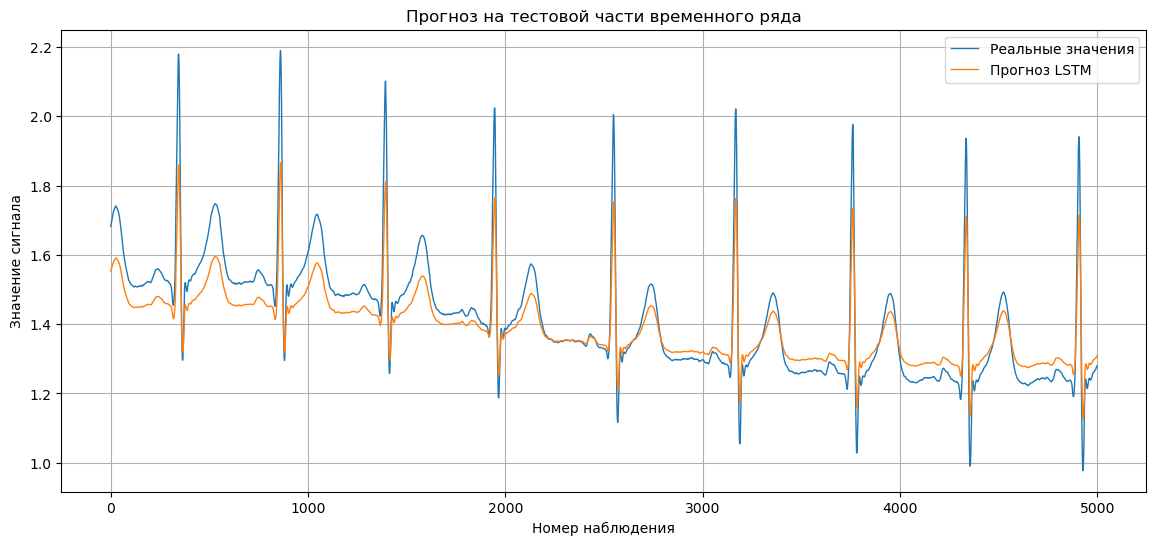

In [14]:
def plot_test_prediction(test, model, lookback=1, max_points=5000):
    dataset = TimeSeriesDataset(test, lookback=lookback)
    loader = DataLoader(dataset,batch_size=4096,shuffle=False,num_workers=0)

    true_values, pred_values = predictions_from_loader(model, loader)

    points = min(max_points, len(true_values))

    plt.figure(figsize=(14, 6))
    plt.plot(true_values[:points],label="Реальные значения",linewidth=1)
    plt.plot(pred_values[:points],label="Прогноз LSTM",linewidth=1)
    plt.title("Прогноз на тестовой части временного ряда")
    plt.xlabel("Номер наблюдения")
    plt.ylabel("Значение сигнала")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_test_prediction(test, model, lookback=lookback)

In [15]:
def validate_on_new_users(model, validation, lookback=1):
    for v in validation:
        calm = validation[v][0]
        work = validation[v][1]
        valid = pd.concat([calm, work], sort=False, axis=0)

        _, valid_test, _ = data_split(valid)

        valid_dataset = TimeSeriesDataset(valid_test, lookback=lookback)
        valid_loader = DataLoader(valid_dataset,batch_size=4096,shuffle=False,num_workers=0)

        true_values, pred_values = predictions_from_loader(model, valid_loader)

        print(f"\nМетрики для пациента {v}:")
        validate(true_values, pred_values)

        points = min(3000, len(true_values))
        plt.figure(figsize=(12, 4))
        plt.plot(true_values[:points], label="Реальные значения")
        plt.plot(pred_values[:points], label="Прогноз")
        plt.title(f"Прогноз для пациента {v}")
        plt.xlabel("Номер наблюдения")
        plt.ylabel("Значение сигнала")
        plt.legend()
        plt.grid(True)
        plt.show()

## Задание 1: Lazy Loading

Смотрите реализацию класса выше

In [16]:
X_example, y_example = train_dataset[0]

print("Количество окон в train_dataset:", len(train_dataset))
print("Количество окон в test_dataset:", len(test_dataset))
print("Размер одного входного окна:", X_example.shape)
print("Размер одного целевого окна:", y_example.shape)

Количество окон в train_dataset: 448899
Количество окон в test_dataset: 221099
Размер одного входного окна: torch.Size([1, 1])
Размер одного целевого окна: torch.Size([1, 1])


## Задание 2: Early Stopping

Реализация функции train_model выше

In [17]:
print("История train RMSE:", train_rmse_history)
print("История test RMSE:", test_rmse_history)
print("Минимальный test RMSE:", min(test_rmse_history))

История train RMSE: [np.float64(0.7723361066861902), np.float64(0.07346521356110727), np.float64(0.06994383143428486), np.float64(0.06538190391397598), np.float64(0.05972968396460102)]
История test RMSE: [np.float64(0.0825319041386616), np.float64(0.079185746797433), np.float64(0.07464351220516437), np.float64(0.06892562927557129), np.float64(0.06190367888419128)]
Минимальный test RMSE: 0.06190367888419128


In [18]:
print("Lazy Loading включён: используется TimeSeriesDataset")
print("Batch size train:", train_loader.batch_size)
print("Batch size test:", test_loader.batch_size)
print("Максимальное число эпох:", EPOCHS)

Lazy Loading включён: используется TimeSeriesDataset
Batch size train: 2048
Batch size test: 4096
Максимальное число эпох: 5


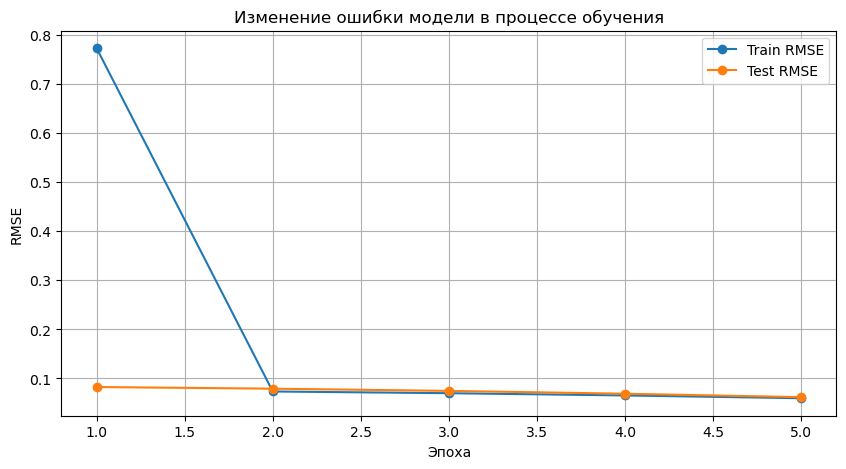

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(train_rmse_history) + 1),
    train_rmse_history,
    marker="o",
    label="Train RMSE"
)

plt.plot(
    range(1, len(test_rmse_history) + 1),
    test_rmse_history,
    marker="o",
    label="Test RMSE"
)

plt.title("Изменение ошибки модели в процессе обучения")
plt.xlabel("Эпоха")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()